<a href="https://colab.research.google.com/github/NawafChukkan/Edtech-digital-wellbeing-ml/blob/main/notebooks/digital_wellbeing_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 EdTech & Digital Wellbeing: Mental Health Risk Prediction
**Author:** Nawaf Chukkan

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://github.com/NawafChukkan/Edtech-digital-wellbeing-ml/blob/main/notebooks/digital_wellbeing_analysis.ipynb)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for professional charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 300

# Load data directly from your public GitHub repository
GITHUB_RAW_URL = "https://raw.githubusercontent.com/NawafChukkan/Edtech-digital-wellbeing-ml/main/social_media_screentime_mental_health_2026.csv"

try:
    df = pd.read_csv(GITHUB_RAW_URL)
    print("✅ Dataset successfully loaded from GitHub!")
except Exception as e:
    print("⚠️ Error loading from GitHub. Please check your username or URL.")

print(f"Dataset Shape: {df.shape}")
df.head(3)

✅ Dataset successfully loaded from GitHub!
Dataset Shape: (7000, 25)


,participant_id,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,...,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band
0,P300000,33,Male,Student,Latin America,TikTok,8,3.2,172,Never,...,9,6,4,6,8,4,No,No,No,At-risk
1,P300001,23,Female,Full-time employed,Oceania,Instagram,8,4.5,38,Often,...,7,5,8,5,8,4,No,"Yes, failed",Yes,At-risk
2,P300002,56,Female,Full-time employed,Africa,Instagram,1,5.3,74,Every night,...,8,7,3,2,3,5,No,No,No,Moderate


/tmp/ipykernel_502/2004531456.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='wellbeing_band', palette='Set2', ax=axes[0],
/tmp/ipykernel_502/2004531456.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='wellbeing_band', y='daily_screen_hours', palette='Set2',
/tmp/ipykernel_502/2004531456.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='wellbeing_band', y='anxiety_score_0to27', palette='Set2',


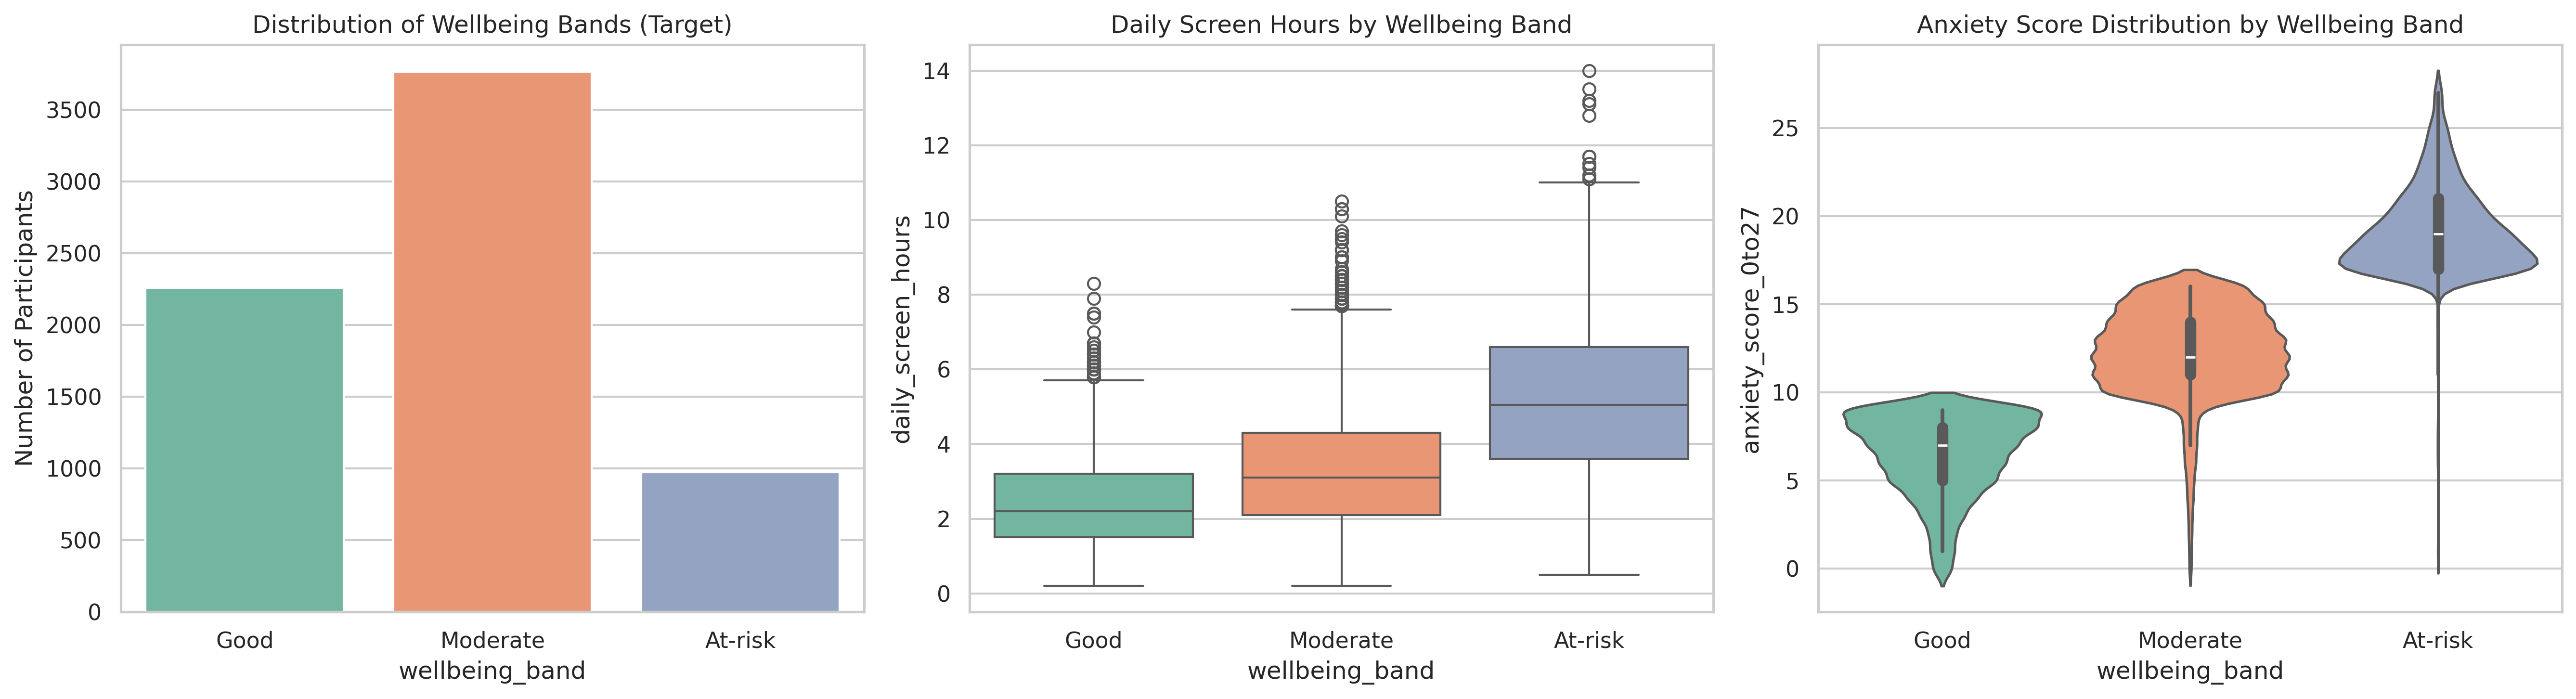

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create the 'assets' folder if it doesn't exist
os.makedirs('assets', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Target Variable Distribution
sns.countplot(data=df, x='wellbeing_band', palette='Set2', ax=axes[0],
              order=['Good', 'Moderate', 'At-risk'])
axes[0].set_title('Distribution of Wellbeing Bands (Target)')
axes[0].set_ylabel('Number of Participants')

# Screen Time vs. Wellbeing
sns.boxplot(data=df, x='wellbeing_band', y='daily_screen_hours', palette='Set2',
            ax=axes[1], order=['Good', 'Moderate', 'At-risk'])
axes[1].set_title('Daily Screen Hours by Wellbeing Band')

# Anxiety Score vs. Wellbeing
sns.violinplot(data=df, x='wellbeing_band', y='anxiety_score_0to27', palette='Set2',
               ax=axes[2], order=['Good', 'Moderate', 'At-risk'])
axes[2].set_title('Anxiety Score Distribution by Wellbeing Band')

plt.tight_layout()
plt.savefig('assets/eda_overview.png')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Impute missing values (Median for numbers, Mode for text)
df['avg_sleep_hours'].fillna(df['avg_sleep_hours'].median(), inplace=True)
df['gender'].fillna(df['gender'].mode()[0], inplace=True)

# Drop metadata that doesn't predict behavior
data = df.drop(columns=['participant_id'])

# Categorical Encoding (One-Hot Encoding)
target_col = 'wellbeing_band'
cat_cols = data.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove(target_col)

data_encoded = pd.get_dummies(data, columns=cat_cols, drop_first=True)

# Define Features (X) and Target (y)
X = data_encoded.drop(columns=[target_col])
y = data_encoded[target_col]

# Train-Test Split (80% Training / 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (5600, 47)
Testing features shape: (1400, 47)


/tmp/ipykernel_502/2774651432.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['avg_sleep_hours'].fillna(df['avg_sleep_hours'].median(), inplace=True)
/tmp/ipykernel_502/2774651432.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# --- Baseline Model: Logistic Regression ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print("=== Logistic Regression (Baseline) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}\n")

# --- Champion Model: Random Forest Classifier ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest Classifier (Champion) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

=== Logistic Regression (Baseline) ===
Accuracy: 0.9171

=== Random Forest Classifier (Champion) ===
Accuracy: 0.9929
              precision    recall  f1-score   support

     At-risk       1.00      0.95      0.97       195
        Good       1.00      1.00      1.00       452
    Moderate       0.99      1.00      0.99       753

    accuracy                           0.99      1400
   macro avg       1.00      0.98      0.99      1400
weighted avg       0.99      0.99      0.99      1400



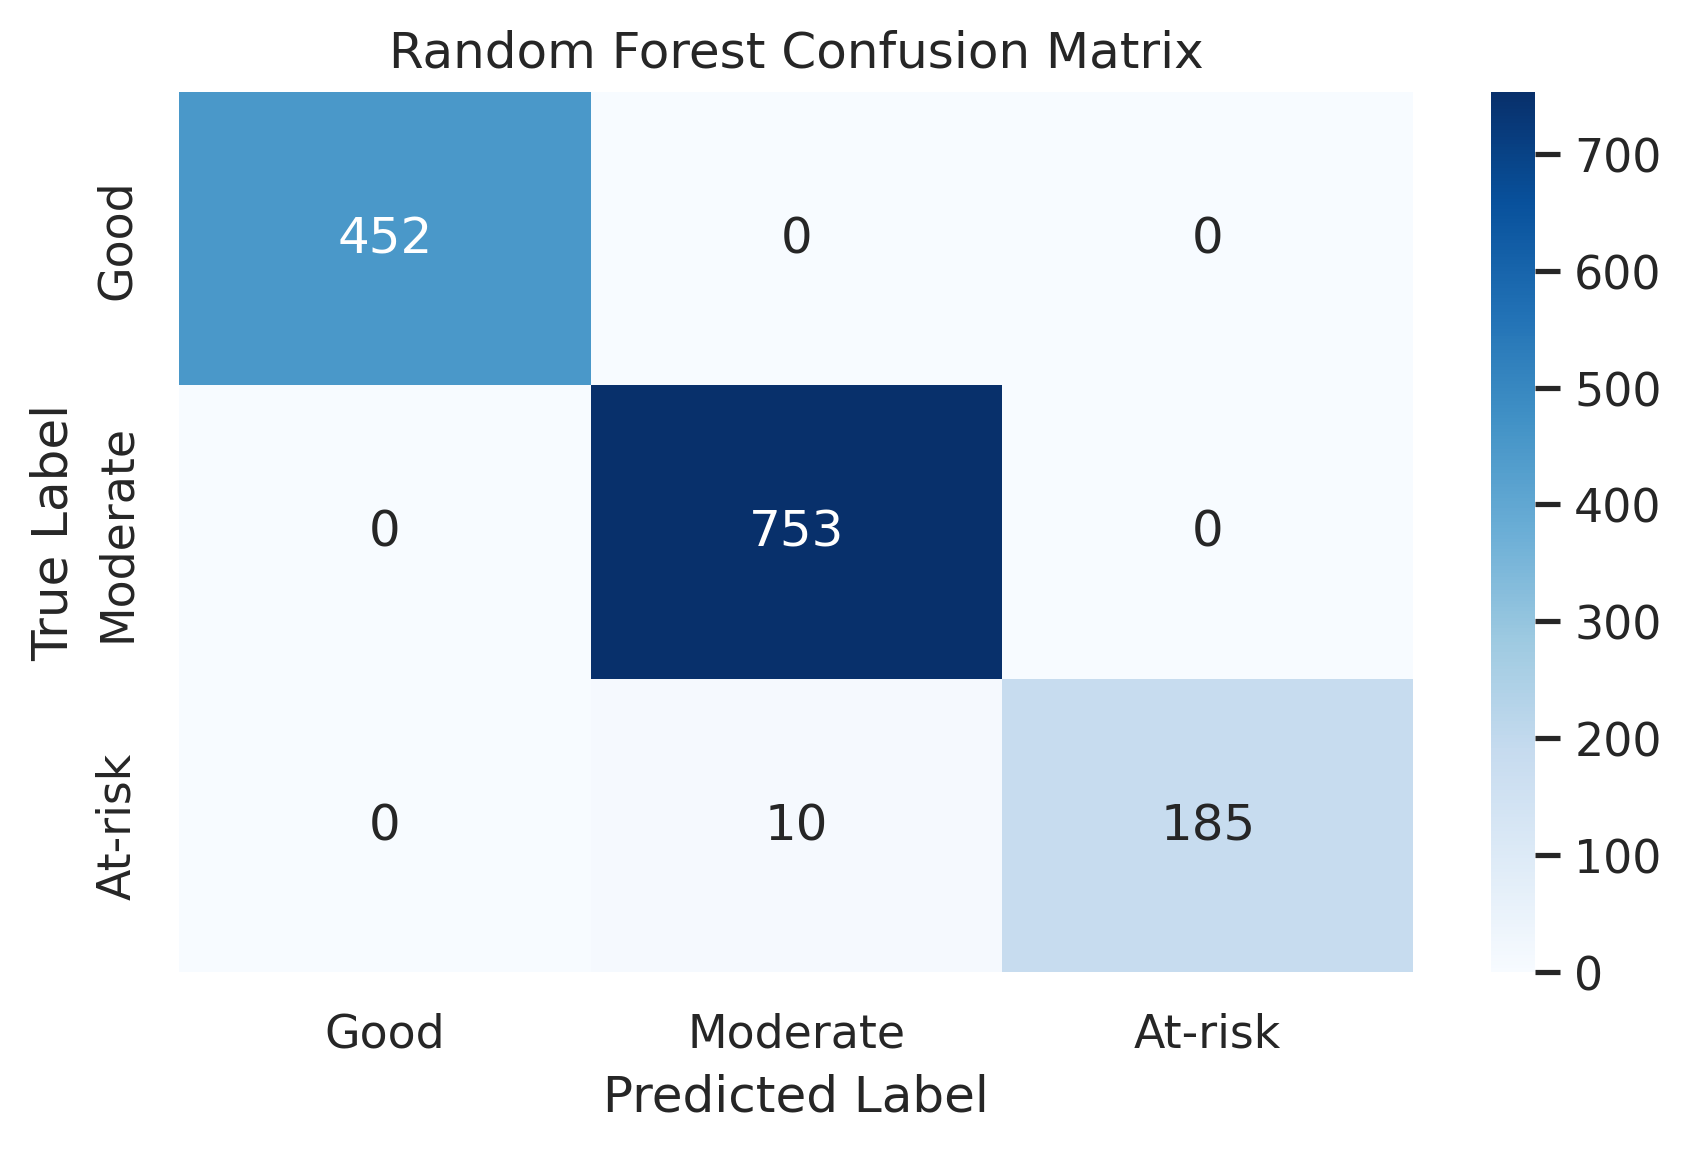

/tmp/ipykernel_502/2388880776.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.head(10).values, y=importances.head(10).index, palette='mako')


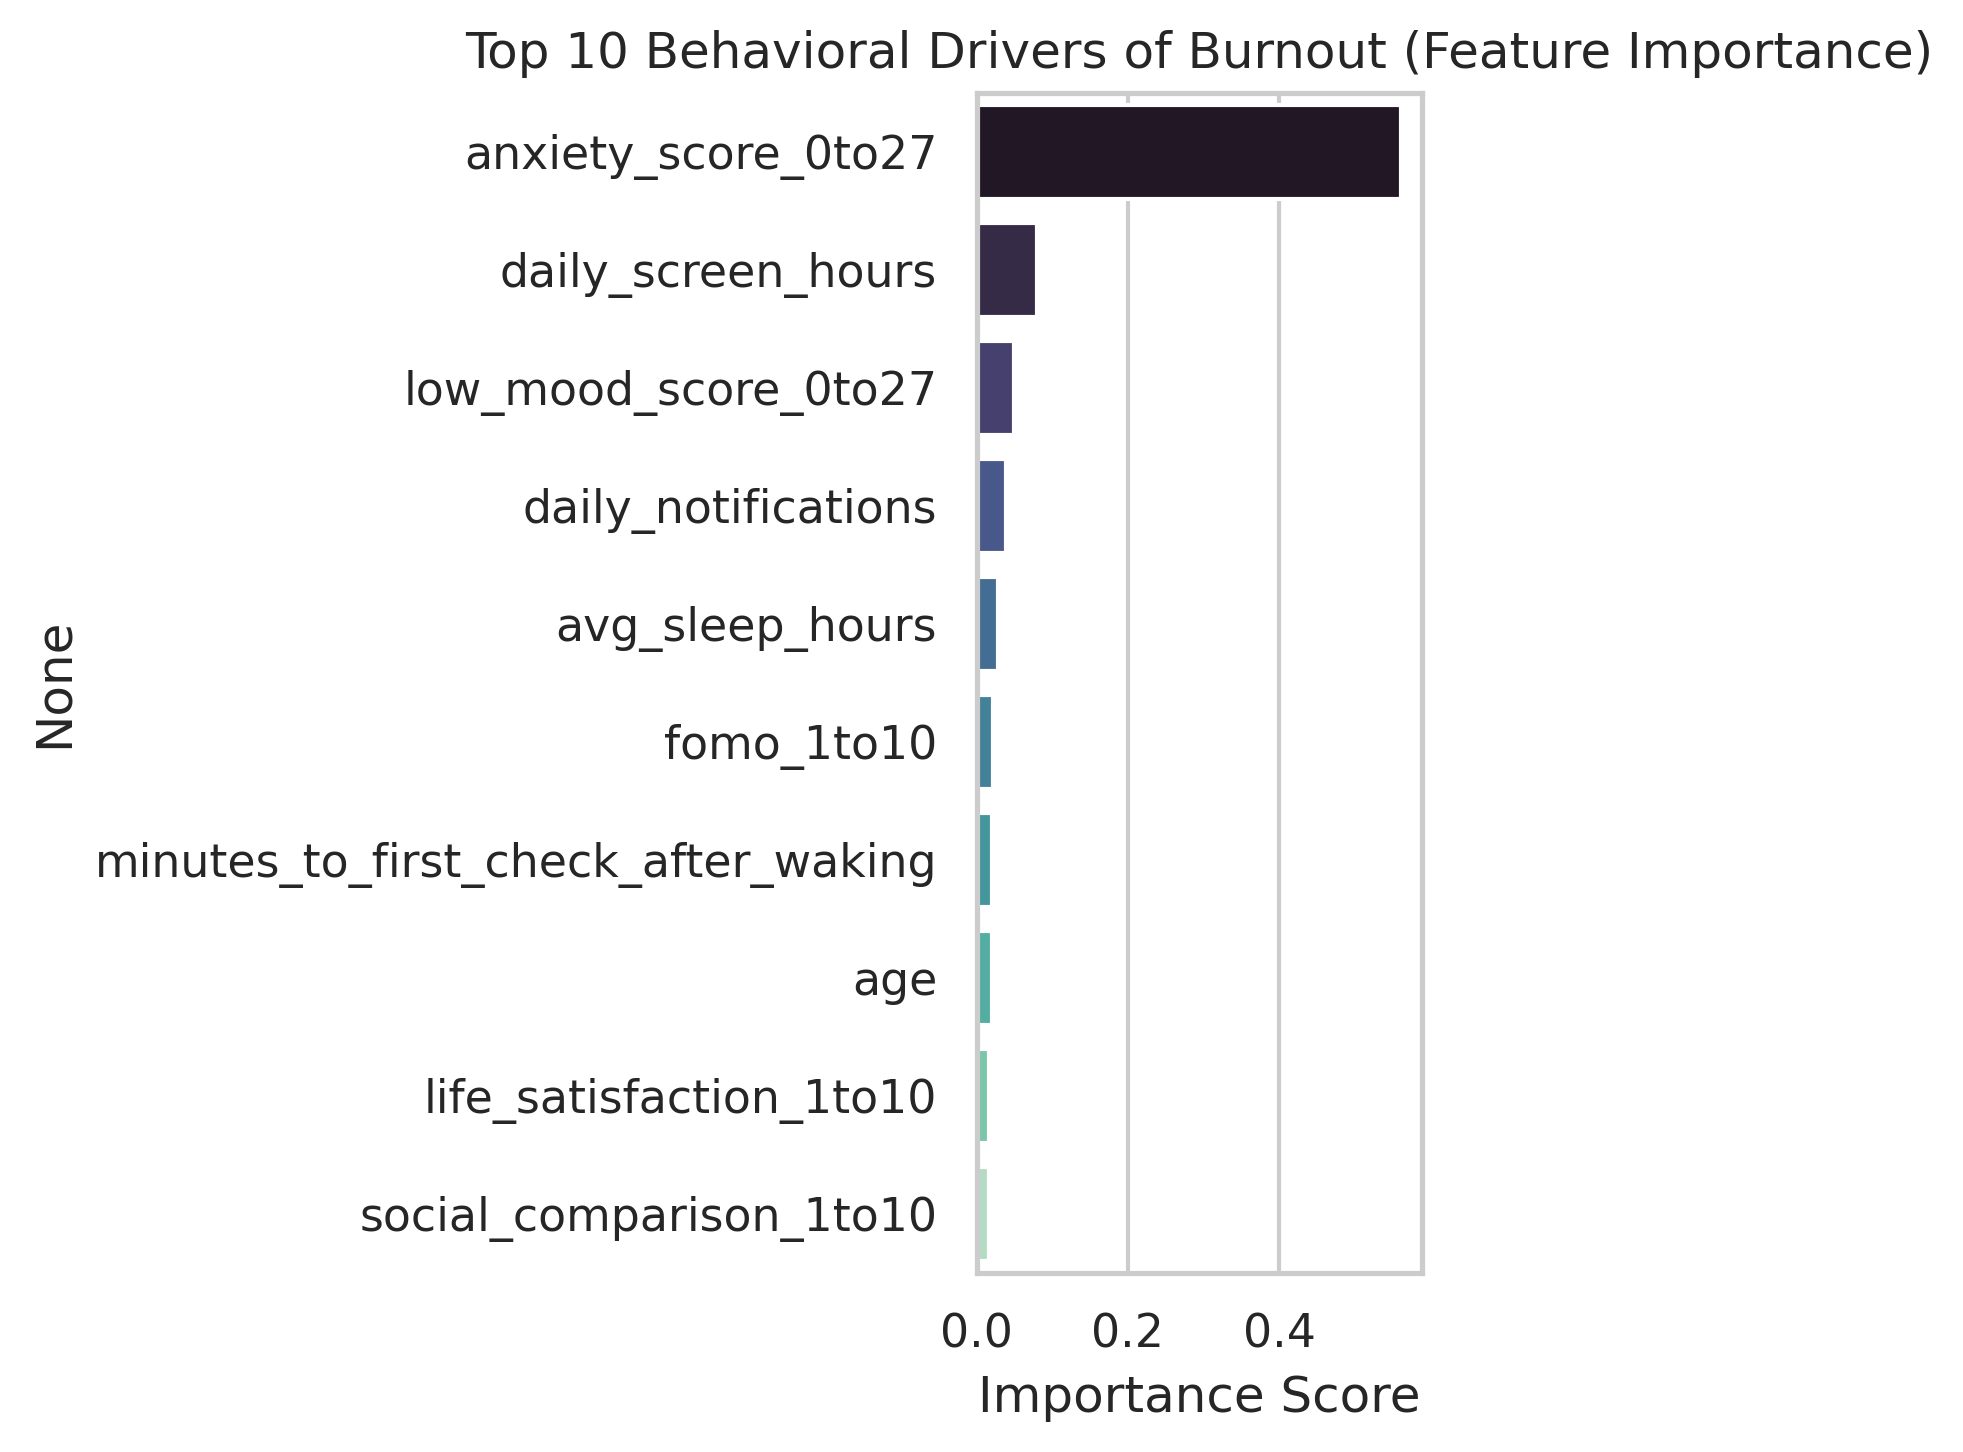

In [16]:
from sklearn.metrics import confusion_matrix

# Make sure the assets folder exists (just in case this cell is run independently)
os.makedirs('assets', exist_ok=True)

# Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_rf, labels=['Good', 'Moderate', 'At-risk'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good', 'Moderate', 'At-risk'],
            yticklabels=['Good', 'Moderate', 'At-risk'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('assets/confusion_matrix.png')
plt.show()

# Feature Importance Chart
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(5, 5))
sns.barplot(x=importances.head(10).values, y=importances.head(10).index, palette='mako')
plt.title('Top 10 Behavioral Drivers of Burnout (Feature Importance)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('assets/feature_importance.png')
plt.show()